# Thử nghiệm các phương pháp sinh giả bất thường: skipframes, patch, noise, fusion

# 1. Create Dataset, Dataloader (with CustomDataset, CustomDataset_ScripFrames)

In [4]:
from pathlib import Path
import torchvision.transforms as transforms
from functions.custom_dataset import *
import torch.utils.data as data
import os
#===========================================
# Path to dataset
#===========================================
project_path = Path('/home/anhnam/Data/VideoAnomaly')
ped2_dataset_folder = Path('/home/dataset/ped2')
train_dir = ped2_dataset_folder / 'training'
test_dir = ped2_dataset_folder / 'testing'

if train_dir.is_dir():
    print(f"{train_dir} directory exists.")

%pwd

#===========================================
# Dataset
#===========================================
transform = transforms.Compose([transforms.ToTensor(),])
resize_height  = 128
resize_width = 128
clip_step = 4
num_pred = 1
skip_frames = [4]
    
train_dataset = CustomDataset(train_dir, transform, 
                            resize_height, resize_width,
                            clip_step, num_pred)
    
train_dataset_skipframes = CustomDataset_SkipFrames(train_dir, transform, 
                            resize_height, resize_width,
                            clip_step, num_pred, skip_frames)

print('len(train_dataset) = ', len(train_dataset))
print('len(train_dataset_skipframes) = ', len(train_dataset_skipframes))

# 1. print dictionary in python
# https://thispointer.com/python-4-ways-to-print-items-of-a-dictionary-line-by-line/
#videos_dict = train_dataset.videos_dict
#for key, value in videos_dict.items():
#    print(key, ' : ', value)

# 2. get first item in dictionary python
# https://thispointer.com/python-get-first-value-in-a-dictionary/
#first_key, first_value = list(videos_dict.items())[0]
#print(first_key, first_value)

#===========================================
# Dataloader
#===========================================
batch_size = 1
num_workers = os.cpu_count() # 80

train_dataloader = data.DataLoader(train_dataset, batch_size = batch_size, 
                              shuffle=False, num_workers = num_workers, drop_last=True)

train_dataloader_skipframes = data.DataLoader(train_dataset_skipframes, batch_size = batch_size, 
                              shuffle=False, num_workers = num_workers, drop_last=True)

#for j,(imgs) in enumerate(train_dataloader):
    #print('j = {0:2d}'.format(j))
    #imgs = Variable(imgs).cuda()
    #print(j)

ModuleNotFoundError: No module named 'functions'

# 2. Open image with PIL and OpenCV

## 2.1. Open image with PIL

In [1]:
from functions.utils import *
from functions.visualize import *

videos_dict = train_dataset.videos_dict
image_path = videos_dict['01']['frames'][0]
print('image_path = ', image_path)

img, height, width = open_image_PIL(image_path)
print(f"Image height: {height}") 
print(f"Image width: {width}")
plot_image_PIL(img)


ModuleNotFoundError: No module named 'functions'

## 2.2. Open image with OpenCV

In [8]:
from functions.utils import *
from functions.visualize import *

videos_dict = train_dataset.videos_dict
image_path = videos_dict['01']['frames'][0]
print('image_path = ', image_path)

img, height, width = open_image_cv2(image_path)
print(f"Image height: {height}") 
print(f"Image width: {width}")
plot_image_cv2(img)

ModuleNotFoundError: No module named 'functions'

## 2.3. Show transformed image (test)

In [9]:
from functions.utils import *
from functions.visualize import *

# Write transform for image
data_transform = transforms.Compose([
    # Resize the images to 64x64
    transforms.Resize(size=(128, 128)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5), # p = probability of flip, 0.5 = 50% chance
    # Turn the image into a torch.Tensor
    transforms.ToTensor() # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.0 
])

image_path_list = videos_dict['01']['frames']
plot_transformed_images(image_path_list, 
                        transform=data_transform, 
                        n=2, seed=42)

ModuleNotFoundError: No module named 'functions'

# 3. Show Normal frames, Skip frames (with CustomDataset, CustomDataset_SkipFrames)


 id_skip_frames =  10

 id_skip_frames =  14

 id_skip_frames =  18

 id_skip_frames =  22

 id_skip_frames =  26


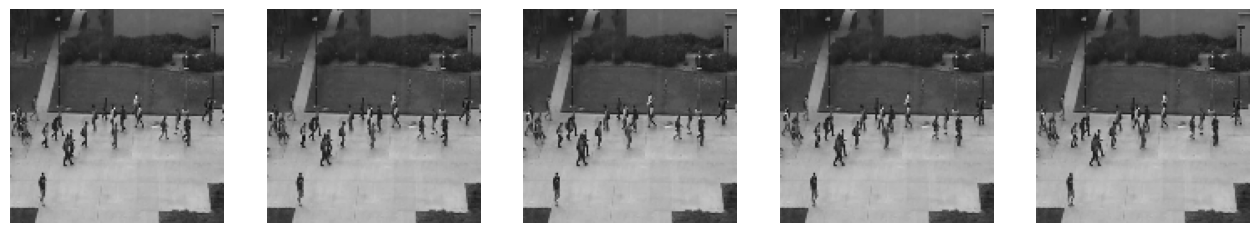

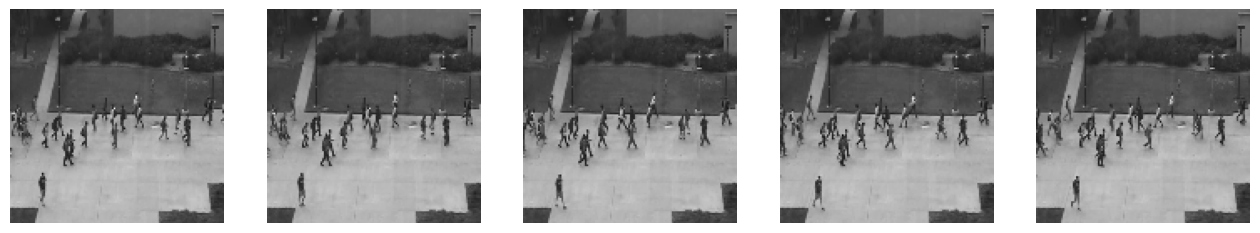

In [2]:
from functions.utils import *
from functions.visualize import *

#==========================================================
# Normal frames
#==========================================================
idx = 10
# clip is 'numpy.ndarray' which contains consecutive frames
clip = train_dataset[idx] # values in [-1,1]

# since each frame img has values in range of [-1,1], need convert img to [0,255], so it can be showed by matplotlib
#print('clip.shape = ', clip.shape) # (15, 128, 128) , 15 = 3 x 5 (channels x (clip_step+num_pred)
#print(clip[0])
#print('clip.dtype = ', clip.dtype) # float32

clip_converted = convert_minus1_1_to_0_255(clip) # values in [0,255]
#print('clip_converted.shape = ', clip_converted.shape) 
#print(clip_converted[0])

plot_clip_cv2(clip_converted)

#==========================================================
# Skip frames
#==========================================================
idx = 10
# clip is 'numpy.ndarray' which contains consecutive frames
clip_skipframes = train_dataset_skipframes[idx] # values in [-1,1]

# since each frame img has values in range of [-1,1], need convert img to [0,255], so it can be showed by matplotlib
#print('clip_skipframes.shape = ', clip_skipframes.shape) # (15, 128, 128) , 15 = 3 x 5 (channels x (clip_step+num_pred)
#print(clip_skipframes[0])
#print('clip_skipframes.dtype = ', clip_skipframes.dtype) # float32

clip_skipframes_converted = convert_minus1_1_to_0_255(clip_skipframes) # values in [0,255]
#print('clip_skipframes_converted.shape = ', clip_skipframes_converted.shape) 
#print(clip_skipframes_converted[0])

plot_clip_cv2(clip_skipframes_converted)

# 4. Patch based Pseudo Anomalies

## 4.1. Ped2, Cifar viewer

In [5]:
from torchvision.datasets.cifar import CIFAR100
import torchvision.transforms as transforms
from functions.custom_dataset import *

from functions.utils import *
from functions.visualize import *

#=================================================
# ped2
#=================================================
original_img_iter = iter(train_dataloader)
original_img = next(original_img_iter)
print('original_img.shape = ', original_img.shape) # torch.Size([1, 15, 128, 128])

original_img_squeeze = original_img.squeeze()
print('original_img_squeeze.shape = ', original_img_squeeze.shape)

original_img_squeeze_255 = convert_tensor_minus1_1_to_0_255(original_img_squeeze) # values in [0,255]
plot_clip_cv2(original_img_squeeze_255)

#=================================================
# CIFAR: dataset and dataloader
#=================================================
cifar_dataset = CIFAR100('dataset/cifar100', train=True, download=True, transform=transforms.ToTensor())
cifar_loader = data.DataLoader(cifar_dataset, batch_size=1, shuffle=False, 
                               num_workers=num_workers, drop_last=True)

cifar_iter = iter(cifar_loader)
cifar_img, _ = next(cifar_iter)
print('cifar_img.shape = ', cifar_img.shape) # torch.Size([1, 3, 32, 32])

cifar_img_squeeze = cifar_img.squeeze()
print('cifar_img_squeeze.shape = ', cifar_img_squeeze.shape)

cifar_img_squeeze_255 = convert_tensor_minus1_1_to_0_255(cifar_img_squeeze) # values in [0,255]
plot_clip_cv2(cifar_img_squeeze_255)

ModuleNotFoundError: No module named 'functions'

## 4.2. Patch: cifar_smooth

In [6]:
from functions.utils import *
from functions.visualize import *

max_size = 0.2
h = 128
w = 128
max_move = 0
original_img_mask, mask = pseudoanomaly_patch_cifar_smooth(original_img_squeeze, cifar_img_squeeze, 
                                            max_size, h, w,
                                            max_move)

# ped2
original_img_mask_squeeze = original_img_mask.squeeze()
print('original_img_squeeze.shape = ', original_img_mask_squeeze.shape)

original_img_mask_squeeze_255 = convert_tensor_minus1_1_to_0_255(original_img_mask_squeeze) # values in [0,255]
plot_clip_cv2(original_img_mask_squeeze_255)

ModuleNotFoundError: No module named 'functions'

## 4.3. Patch: cifar_smoothborder

In [7]:
from functions.utils import *
from functions.visualize import *

max_size = 0.2
h = 128
w = 128
max_move = 0
original_img_mask, mask = pseudoanomaly_patch_cifar_smoothborder(original_img_squeeze, cifar_img_squeeze, 
                                            max_size, h, w,
                                            max_move)

# ped2
original_img_mask_squeeze = original_img_mask.squeeze()
print('original_img_squeeze.shape = ', original_img_mask_squeeze.shape)

original_img_mask_squeeze_255 = convert_tensor_minus1_1_to_0_255(original_img_mask_squeeze) # values in [0,255]
plot_clip_cv2(original_img_mask_squeeze_255)

ModuleNotFoundError: No module named 'functions'

# 5. Fusion based Pseudo Anomalies

## 5.2. Ped2: images_1, image_2 viewer

img_1.shape =  torch.Size([1, 15, 128, 128])
img_1_squeeze.shape =  torch.Size([15, 128, 128])
img_2.shape =  torch.Size([1, 15, 128, 128])
img_2_squeeze.shape =  torch.Size([15, 128, 128])


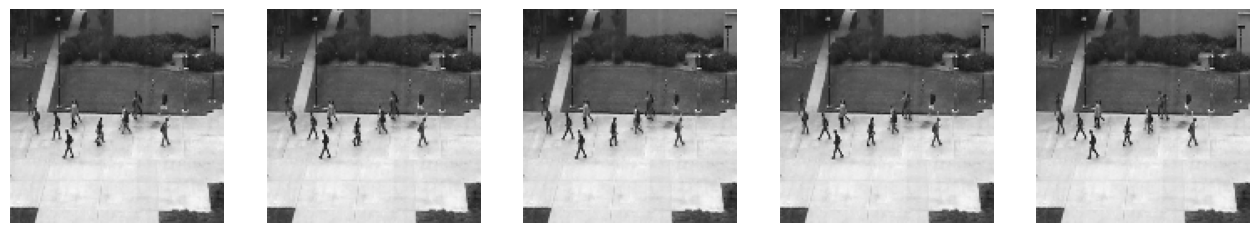

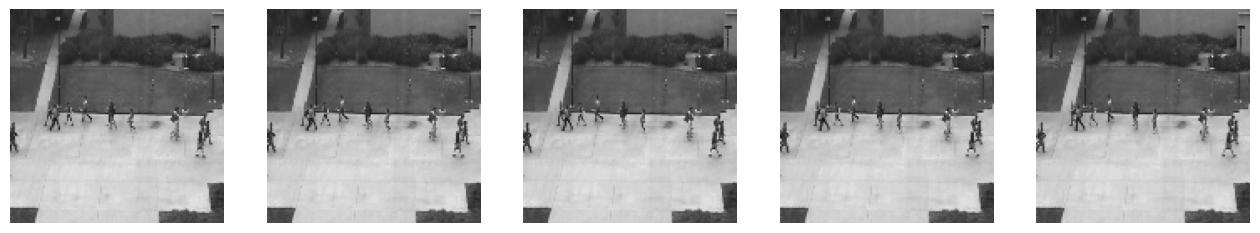

In [15]:
from torchvision.datasets.cifar import CIFAR100
import torchvision.transforms as transforms
from functions.custom_dataset import *

from functions.utils import *
from functions.visualize import *

train_dataloader_1 = data.DataLoader(train_dataset, batch_size = batch_size, 
                              shuffle=True, num_workers = num_workers, drop_last=True)

train_dataloader_2 = data.DataLoader(train_dataset, batch_size = batch_size, 
                              shuffle=True, num_workers = num_workers, drop_last=True)
#=================================================
# ped2_1
#=================================================
img_iter_1 = iter(train_dataloader_1)
img_1 = next(img_iter_1)

print('img_1.shape = ', img_1.shape) # torch.Size([1, 15, 128, 128])

img_1_squeeze = img_1.squeeze()
print('img_1_squeeze.shape = ', img_1_squeeze.shape)

img_1_squeeze_255 = convert_tensor_minus1_1_to_0_255(img_1_squeeze) # values in [0,255]
plot_clip_cv2(img_1_squeeze_255)

#=================================================
# ped2_2
#=================================================
img_iter_2 = iter(train_dataloader_2)
img_2 = next(img_iter_2)

print('img_2.shape = ',img_2.shape) # torch.Size([1, 15, 128, 128])

img_2_squeeze = img_2.squeeze()
print('img_2_squeeze.shape = ', img_2_squeeze.shape)

img_2_squeeze_255 = convert_tensor_minus1_1_to_0_255(img_2_squeeze) # values in [0,255]
plot_clip_cv2(img_2_squeeze_255)

## 5.2. Fusion

img_fusion_squeeze.shape =  torch.Size([15, 128, 128])


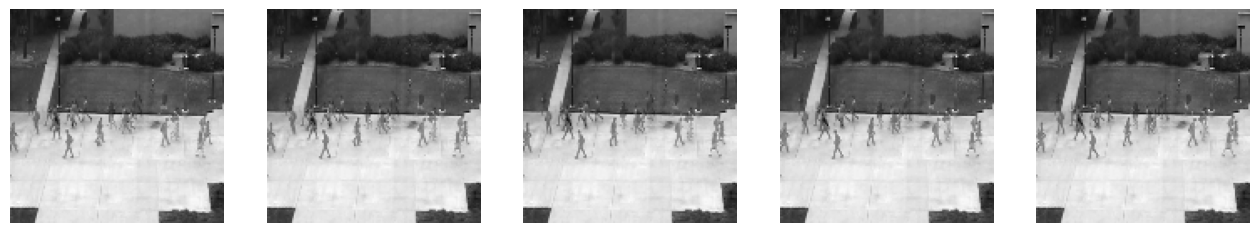

In [16]:
from functions.utils import *
from functions.visualize import *

mask = 0.5
img_fusion = pseudoanomaly_fusion(img_1_squeeze, img_2_squeeze, mask)

# ped2
img_fusion_squeeze = img_fusion.squeeze()
print('img_fusion_squeeze.shape = ', img_fusion_squeeze.shape)

img_fusion_squeeze_255 = convert_tensor_minus1_1_to_0_255(img_fusion_squeeze) # values in [0,255]
plot_clip_cv2(img_fusion_squeeze_255)

## 5.3. Noise

img_1_squeeze.shape =  torch.Size([15, 128, 128])
img_noise_squeeze.shape =  torch.Size([15, 128, 128])


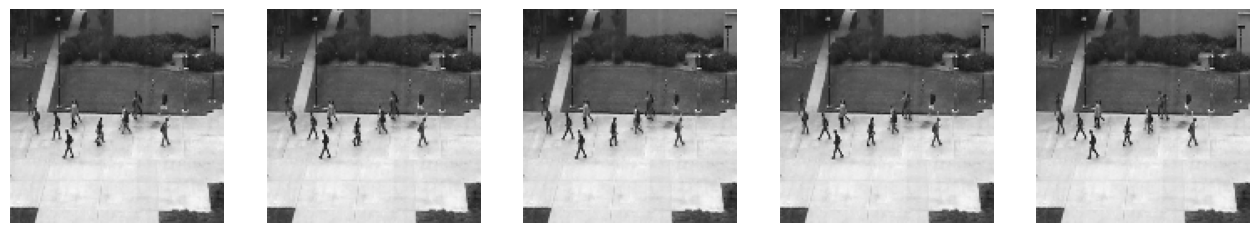

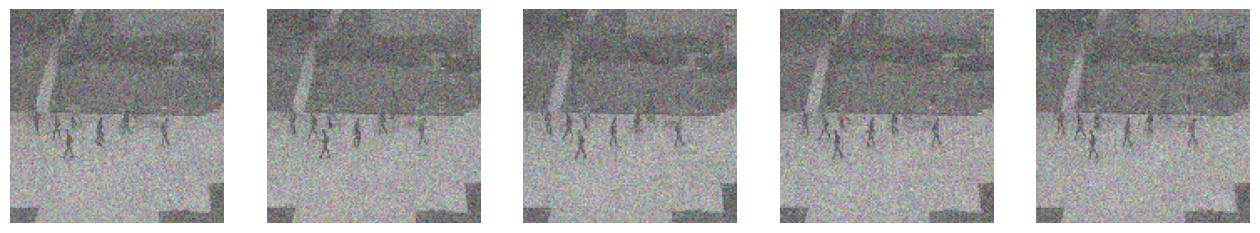

In [22]:
from functions.utils import *
from functions.visualize import *

# original image
img_1_squeeze = img_1.squeeze()
print('img_1_squeeze.shape = ', img_1_squeeze.shape)
img_1_squeeze_255 = convert_tensor_minus1_1_to_0_255(img_1_squeeze) # values in [0,255]
plot_clip_cv2(img_1_squeeze_255)

# add noise
mean = 0.0
std = 0.05
img_noise = pseudoanomaly_noise(img_1_squeeze, mean, std)

# noise image
img_noise_squeeze = img_noise.squeeze()
print('img_noise_squeeze.shape = ', img_noise_squeeze.shape)
img_noise_squeeze_255 = convert_tensor_minus1_1_to_0_255(img_noise_squeeze) # values in [0,255]
plot_clip_cv2(img_noise_squeeze_255)

In [5]:
import glob
import os

score = [1, 2, 3, 4, 5]

vid_idx_list = []

test_folder = '/home/dataset/ped2/testing'
videos_list = sorted(glob.glob(os.path.join(test_folder, '*')))
for i, video in enumerate(sorted(videos_list)):
    print('i = ', i)
    vid_idx_list += [i for _ in range(len(score))]

print('vid_idx_list = ', vid_idx_list)

vid_idx_list =  []
